In [47]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns

In [48]:
X=2*np.random.randn(100)
y=4+3*X+np.random.randn(100)

<Axes: >

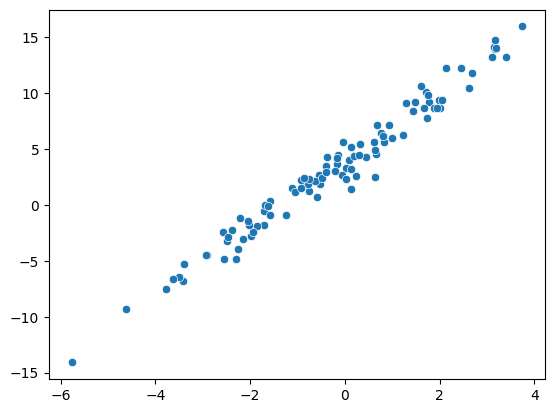

In [49]:
sns.scatterplot(x=X,y=y)

In [50]:
x_mean=X.mean()
y_mean=y.mean()

print("X mean : ", x_mean,"\nY mean : ",y_mean)

X mean :  -0.20962821502704732 
Y mean :  3.3018422739348443


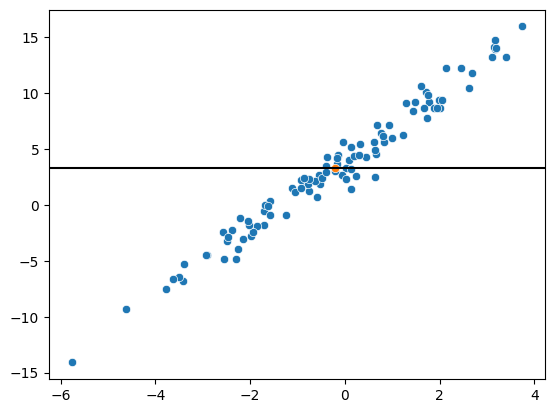

In [51]:
sns.scatterplot(x=X,y=y)
sns.scatterplot(x=[x_mean],y=[y_mean])
plt.axhline(y=y_mean, color="black")
plt.show()

The equation of line is:

y=mx+b

In [53]:
def predict(x,m,b):
    return m*x+b

Loss Function (MSE)

In [54]:
def compute_loss(x,y,m,b):
    n=len(x)
    total_error=0
    for i in range(n):
        y_pred=predict(m,x[i],b)
        error=y[i]-y_pred
        total_error+=error*error
    return total_error/n

Compute Gradients

In [55]:
def compute_gradients(x, y, m, b):
    n = len(x)
    dm = 0
    db = 0

    for i in range(n):
        y_pred = predict(m,x[i],b)
        error = y[i] - y_pred

        dm += -2 * x[i] * error
        db += -2 * error

    dm /= n
    db /= n

    return dm, db

In [56]:
def train(x, y, m, b, alpha, epochs):
    for i in range(epochs):
        dm, db = compute_gradients(x, y, m, b)

        m = m - alpha * dm
        b = b - alpha * db
        loss = compute_loss(X, y, m, b)
        print("Loss is: ",loss)
    return m, b

Test

In [57]:
m=0    # slope
b=0    # intercept

In [58]:
alpha = 0.01   # learning rate
epochs = 1000  # number of iterations

In [59]:
m, b = train(X, y, m, b, alpha, epochs)

Loss is:  40.68448495199276
Loss is:  36.57532921380858
Loss is:  33.00516590898232
Loss is:  29.8969685811675
Loss is:  27.184996652565037
Loss is:  24.813130598771814
Loss is:  22.733453150367485
Loss is:  20.905040146307623
Loss is:  19.292930042881245
Loss is:  17.867245665316748
Loss is:  16.602445694699128
Loss is:  15.476686710911933
Loss is:  14.471279448241878
Loss is:  13.570225336855513
Loss is:  12.759821462586872
Loss is:  12.02832383220365
Loss is:  11.365660326575743
Loss is:  10.76318599832242
Loss is:  10.213474456258622
Loss is:  9.71014000415703
Loss is:  9.247685989732496
Loss is:  8.821375491567267
Loss is:  8.427121044169827
Loss is:  8.061390589184985
Loss is:  7.7211272564662226
Loss is:  7.403680932948768
Loss is:  7.106749879113341
Loss is:  6.828330910049933
Loss is:  6.566676877318854
Loss is:  6.320260374586134
Loss is:  6.087742749173857
Loss is:  5.867947637297926
Loss is:  5.659838356343945
Loss is:  5.462498586023679
Loss is:  5.275115854184454
Loss is:

Best Fit

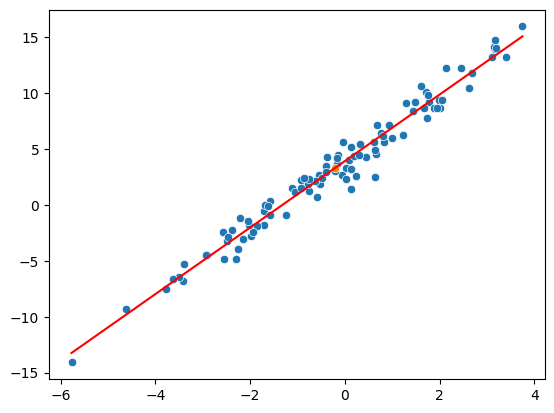

In [61]:
sns.scatterplot(x=X,y=y)
sns.scatterplot(x=[x_mean],y=[y_mean])

x_line = np.linspace(X.min(), X.max(), 100)
y_line = m * x_line + b
plt.plot(x_line, y_line, color='red')
plt.show()

In [40]:
def compute_r2(x, y, m, b):
    n = len(x)
    
    # mean of y
    y_mean = sum(y) / n
    
    ss_res = 0
    ss_tot = 0
    
    for i in range(n):
        y_pred = m * x[i] + b
        
        ss_res += (y[i] - y_pred) ** 2
        ss_tot += (y[i] - y_mean) ** 2
    
    r2 = 1 - (ss_res / ss_tot)
    return r2

In [62]:
r2=compute_r2(X,y,m,b)
print(f"Your model explains {100*r2:.2f}% of variation.")

Your model explains 97.13% of variation.
